# Solver comparison: eigendecomposition vs. matrix exponential

Compares `modesolver="eig"` (`docs/eigenproblem.md`) against `modesolver="matexp"`
(`docs/matrixexp.md`) on the same dielectric metasurface family as `2d_grating.ipynb`. Both give
the same reflectance; the cells below check that, then compare timing and accuracy across
`dtype` and `Config.matexp_gap`.

In [1]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace
from typing import Sequence, Tuple

from dispertorch import ConstantEps, ConstantIndex
from metashapes.shape import Rectangle, Ellipse, RegularPolygon

from metarcwa import IsotropicMedium, Source, Stack, Lattice, Model, Layer
from metarcwa.model.adapters import from_dispertorch, from_metashapes
from metarcwa import Config, Solver, Factorization, Observables
from metarcwa.solver.harmonics import harmonic_index_map

In [2]:
def build_model(w: torch.Tensor,
                h: torch.Tensor,
                angle: torch.Tensor,
                thickness: torch.Tensor,
                eps_solid: ConstantEps,
                eps_void: ConstantEps,
                eps_inc: ConstantEps,
                eps_trans: ConstantEps,
                period: torch.Tensor,
                wl: torch.Tensor,
                theta: torch.Tensor) -> Model:
    """Build a single-patterned-layer Model between two half-spaces.

    The layer's in-plane permittivity is ``shape`` (filled with ``eps_solid``)
    embedded in a background of ``eps_void``, on a square lattice of period
    ``period``. The layer sits between an incidence half-space (``eps_inc``)
    and a transmission half-space (``eps_trans``).

    Parameters
    ----------
    w: torch.Tensor
        Bar width.
    thickness : torch.Tensor
        Layer thickness.
    eps_solid, eps_void : ConstantEps
        Dispersion models for the shape's fill / background, wrapped into
        ``IsotropicMedium`` via ``from_dispertorch``.
    eps_inc, eps_trans : ConstantEps
        Dispersion models for the incidence / transmission half-spaces.
    period : torch.Tensor
        Square lattice period (px = py).
    wl : torch.Tensor
        Free-space wavelength(s).
    theta : torch.Tensor
        Polar incidence angle(s) in radians, measured from the interface
        normal.

    Returns
    -------
    Model
        Ready to pass to ``Solver``.
    """
    medium_inc = IsotropicMedium(from_dispertorch(eps_inc))
    medium_trans = IsotropicMedium(from_dispertorch(eps_trans))
    medium_solid = IsotropicMedium(from_dispertorch(eps_solid))
    medium_void = IsotropicMedium(from_dispertorch(eps_void))

    lattice = Lattice.rectangular(px=period, py=period)
    layer = Layer(medium_solid, thickness, medium_void, 
                  from_metashapes(Ellipse((period/2, period/2), (w, h), angle)))
    stack = Stack(medium_inc, [layer], medium_trans, lattice)
    src = Source(wl, theta, phi=0.0)

    return Model(stack, src)


def build_config(dtype: torch.dtype, device: torch.device,
                 m: int, n: int, nx: int, ny: int,
                 factorization: Factorization | None,
                 truncation: str = "circular",
                 modesolver: str = "eig") -> Config:
    """Build a Config from a Factorization instance directly (or None to
    disable TVF). Kept separate from `Factorization(...)` construction so
    callers can build variant configs via `dataclasses.replace(base_config, ...)`.
    """
    return Config(dtype, device, m=m, n=n, nx=nx, ny=ny,
                  truncation=truncation, factorization=factorization, modesolver=modesolver)
    
def compute_rt(model: Model, config: Config) -> Tuple[torch.Tensor, torch.Tensor,
                                                        torch.Tensor, torch.Tensor]:
    """Solve the stack and return specular-order power R/T for both polarizations.

    Same convention as ``interface.ipynb``'s ``compute_rt``: reflectance is
    ``|r|**2``; transmittance additionally carries the Poynting-flux ratio
    ``Re(n_sub*cos(theta_t)) / Re(n_inc*cos(theta_i))`` between the incidence
    and transmission half-spaces (unaffected by whatever finite layer sits in
    between -- it depends only on the two half-spaces and the angle).

    Returns
    -------
    Rs, Rp, Ts, Tp : torch.Tensor
        Shape ``[N_wl, N_theta, N_phi]``, matching ``Source``'s sweep axes.
    """
    solver = Solver(model, config)
    solution = solver.run()
    obs = Observables(solution)

    rs, _ = obs.reflection(pol='s')
    _, rp = obs.reflection(pol='p')
    Rs = torch.abs(rs.cpu())**2
    Rp = torch.abs(rp.cpu())**2

    ts, _ = obs.transmission(pol='s')
    _, tp = obs.transmission(pol='p')

    n1 = (model.stack.incidence.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)
    n2 = (model.stack.transmission.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)

    theta = model.source.theta.cpu().reshape(1, -1, 1)
    cos_i = torch.cos(theta)
    sin_t = (n1 / n2) * torch.sin(theta)
    cos_t = torch.sqrt(1 - sin_t**2 + 0j)
    coeff = torch.real(n2 * cos_t) / torch.real(n1 * cos_i)

    Ts = coeff * torch.abs(ts.cpu())**2
    Tp = coeff * torch.abs(tp.cpu())**2
    return Rs, Rp, Ts, Tp

Eigensolver time: 6.5148186683654785 s


Matrix Exponential time: 2.2381062507629395 s


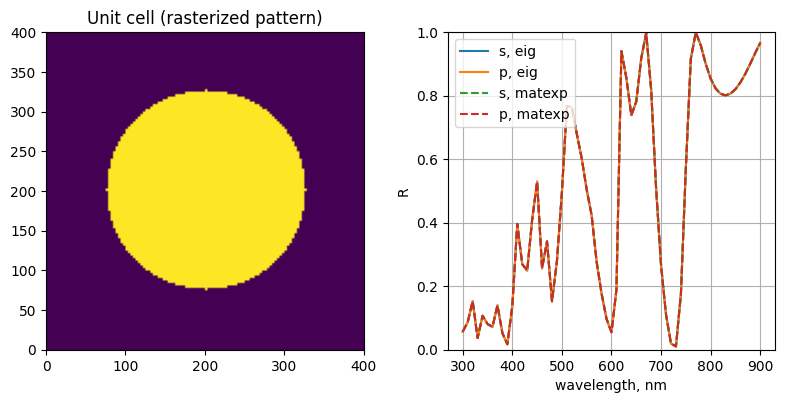

In [3]:
# Define config
dtype = torch.float32
device = "cuda:1"
m = 10
n = 10
nx = 128
ny = 128
truncation = "circular"
factorization = Factorization(method="Jones")


# Define model parameters
eps_inc  = ConstantEps(1)
eps_solid  = ConstantIndex(3.8, k=0.0)    
eps_subs = ConstantIndex(1.46)

w = torch.tensor(250.0)
h = torch.tensor(250.0)
angle = 0.0
thickness = torch.tensor(200.0)   # nm
period    = 400

wl    = torch.linspace(300.0, 900.0, 61)
theta = torch.tensor([0.0])       # ~17 deg, fixed

model = build_model(w, h, angle, thickness, eps_solid, eps_inc, eps_inc, eps_subs, period, wl, theta)

# Eigensolver
modesolver = "eig"
config_eig = build_config(dtype, device, m, n, nx, ny, factorization, truncation, modesolver=modesolver)
start = time.time()
Rs_eig, Rp_eig, Ts_eig, Tp_eig = compute_rt(model, config_eig)
end = time.time()
print(f"Eigensolver time: {end - start} s")

# Matrix exponential solver
modesolver = "matexp"
config_matexp = build_config(dtype, device, m, n, nx, ny, factorization, truncation, modesolver=modesolver)
start = time.time()
Rs_matexp, Rp_matexp, Ts_matexp, Tp_matexp = compute_rt(model, config_matexp)
end = time.time()
print(f"Matrix Exponential time: {end - start} s")

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(model.spec(nx=nx, ny=ny).layers[0].pattern.cpu(), origin="lower", extent=(0, period, 0, period))
plt.title("Unit cell (rasterized pattern)")

plt.subplot(122)
plt.plot(wl, Rs_eig[:,0,0], label='s, eig')
plt.plot(wl, Rp_eig[:,0,0], label='p, eig')
plt.plot(wl, Rs_matexp[:,0,0], '--', label='s, matexp')
plt.plot(wl, Rp_matexp[:,0,0], '--', label='p, matexp')
plt.grid()
plt.ylabel('R')
plt.xlabel('wavelength, nm')
plt.legend()
plt.ylim([0, 1.0])

plt.tight_layout()

## `matexp` settings

Two settings affect `matexp`'s speed and accuracy relative to `eig`:

**`dtype`.** `matexp` replaces `eig`'s eigendecomposition with a dense `matrix_exp`, which is
GEMM-bound and much slower in `complex128` on consumer GPUs — their `float64` throughput is a
small fraction of `float32`. `eig` is less sensitive to precision, since `torch.linalg.eig` is
latency-bound rather than GEMM-bound. `matexp`'s speed advantage over `eig` is therefore largest
at `float32` and shrinks at `float64`. See `docs/matrixexp.md` "Cost model".

**`Config.matexp_gap`.** `matexp` slices the layer internally and references each slice's
S-matrix to a homogeneous "gap medium" before recombining. The default, `"mean"`, uses the
layer's own mean permittivity; `"max"` uses its peak permittivity, for better `float32`
conditioning; `"vacuum"` references every slice to vacuum instead. All three give the same
answer in exact arithmetic — the choice only affects `float32` accuracy. See
`docs/matrixexp.md` "Accuracy and conditioning".

The cells below measure timing across `dtype`/`modesolver`, then `float32` accuracy across
`matexp_gap`, against an `eig`/`float64` reference.

In [4]:
import warnings

def time_split(model_, config):
    """Time Solver.__init__ (prepare) and .run() (assemble/cascade) separately."""
    dev = torch.device(config.device)
    if dev.type == "cuda":
        torch.cuda.synchronize(dev)
    t0 = time.time()
    solver = Solver(model_, config)
    if dev.type == "cuda":
        torch.cuda.synchronize(dev)
    t1 = time.time()
    solution = solver.run()
    if dev.type == "cuda":
        torch.cuda.synchronize(dev)
    t2 = time.time()
    return solver, solution, t1 - t0, t2 - t1

# A reduced wavelength subset keeps this memory-safe on modest GPUs -- matexp
# densifies a 4Nh x 4Nh system matrix per slice, ~4x the eig path's 2Nh x 2Nh.
wl_timing = wl[:20]
model_timing = build_model(w, h, angle, thickness, eps_solid, eps_inc, eps_inc,
                            eps_subs, period, wl_timing, theta)

print(f"{'dtype':10s} {'modesolver':10s} {'init (s)':>10s} {'run (s)':>10s} {'total (s)':>10s}")
for dt in (torch.float32, torch.float64):
    for ms in ("eig", "matexp"):
        cfg = build_config(dt, device, m, n, nx, ny, factorization, truncation, modesolver=ms)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            solver, solution, t_init, t_run = time_split(model_timing, cfg)
        print(f"{str(dt).split('.')[-1]:10s} {ms:10s} {t_init:10.2f} {t_run:10.2f} {t_init + t_run:10.2f}")
        del solver, solution
        if torch.device(device).type == "cuda":
            torch.cuda.empty_cache()

dtype      modesolver   init (s)    run (s)  total (s)


float32    eig              1.99       0.23       2.22


float32    matexp           0.74       0.64       1.38


float64    eig              6.47       2.12       8.60


float64    matexp           0.80       7.47       8.27


/home/rodionsa/Code/metarcwa/src/metarcwa/solver/layersolver/matexpsolver.py:414: RuntimeWarning: star_power: intermediate S-matrix magnitude 129 at an accumulation step exceeds the resonance guard (50 for torch.complex64). This usually means a fictitious gap-medium-embedded matexp sub-slab hit a spurious near-pole (see Config.matexp_gap), or the layer is under-sliced for the accuracy budget; either way, accuracy at this wavelength/geometry is suspect. Try a different matexp_slices or matexp_gap, or dtype=torch.float64 (see docs/matrixexp.md 'Accuracy and conditioning').
  S_gap = star_power(S_slice, n)


                    max|dR|    rms|dR|
eig                2.96e-04   9.15e-05
matexp (vacuum)    1.52e-03   2.41e-04
matexp (mean)      6.68e-04   9.98e-05
matexp (max)       3.12e-04   5.47e-05


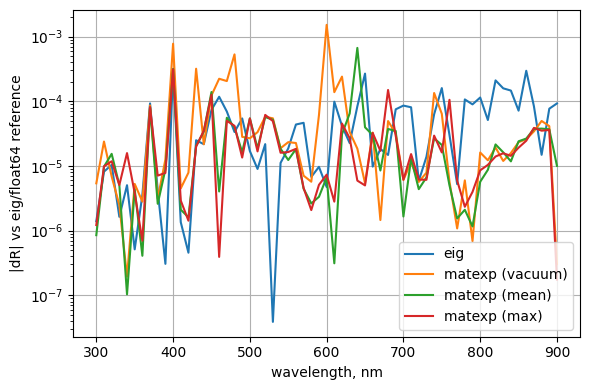

In [5]:
# --- float32 accuracy against an eig/float64 reference ---
# Chunked over wavelength to bound peak memory regardless of GPU size.
def compute_rt_chunked(config, chunk=10):
    Rs_l, Rp_l, Ts_l, Tp_l = [], [], [], []
    for i in range(0, wl.shape[0], chunk):
        wl_chunk = wl[i:i + chunk]
        m_chunk = build_model(w, h, angle, thickness, eps_solid, eps_inc, eps_inc,
                               eps_subs, period, wl_chunk, theta)
        Rs_c, Rp_c, Ts_c, Tp_c = compute_rt(m_chunk, config)
        Rs_l.append(Rs_c); Rp_l.append(Rp_c); Ts_l.append(Ts_c); Tp_l.append(Tp_c)
        del m_chunk
        if torch.device(config.device).type == "cuda":
            torch.cuda.empty_cache()
    return torch.cat(Rs_l), torch.cat(Rp_l), torch.cat(Ts_l), torch.cat(Tp_l)

config_ref = build_config(torch.float64, device, m, n, nx, ny, factorization, truncation, modesolver="eig")
Rs_ref, *_ = compute_rt_chunked(config_ref)

config_eig32 = build_config(torch.float32, device, m, n, nx, ny, factorization, truncation, modesolver="eig")
Rs_eig32, *_ = compute_rt_chunked(config_eig32)

results = {"eig": Rs_eig32}
for gap in ("vacuum", "mean", "max"):
    cfg = replace(
        build_config(torch.float32, device, m, n, nx, ny, factorization, truncation, modesolver="matexp"),
        matexp_gap=gap,
    )
    results[f"matexp ({gap})"] = compute_rt_chunked(cfg)[0]

print(f"{'':16s} {'max|dR|':>10s} {'rms|dR|':>10s}")
for name, Rs in results.items():
    d = (Rs[:, 0, 0] - Rs_ref[:, 0, 0]).abs()
    print(f"{name:16s} {float(d.max()):10.2e} {float((d ** 2).mean() ** 0.5):10.2e}")

plt.figure(figsize=(6, 4))
for name, Rs in results.items():
    plt.plot(wl, (Rs[:, 0, 0] - Rs_ref[:, 0, 0]).abs(), label=name)
plt.yscale('log')
plt.grid()
plt.xlabel('wavelength, nm')
plt.ylabel('|dR| vs eig/float64 reference')
plt.legend()
plt.tight_layout()